1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
고유문자=53  X=(4980, 20)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 20, 32)         │         1,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 53)             │         3,445 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,973 (117.08 KB)

 Trainable params: 29,973 (117.08 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.1336 - loss: 3.6682
Epoch 2/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1549 - loss: 3.1870
Epoch 3/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1673 - loss: 3.1091
Epoch 4/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2155 - loss: 2.9643
Epoch 5/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2455 - loss: 2.7989
Epoch 6/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2910 - loss: 2.6655
Epoch 7/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3036 - loss: 2.5681
Epoch 8/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3079 - loss: 2.4941
Epoch 9/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3188 - loss: 2.4350
Epoch 10/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3320 - loss: 2.3842


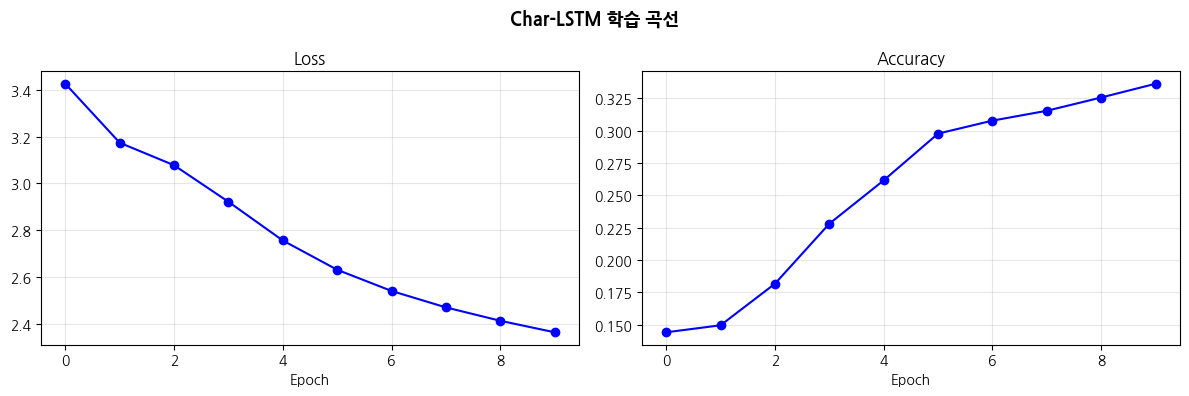


[T=0.2]   the ant the an the the an the ant the an he the are the an the an the all the ane he the ane the an the ane sous the the an the the are the an the an

[T=0.5]  e beu the he rat care sou the here the als the us the sall
Anle the the an hous the ard there at woud un toul to sour, gours souren mar sot ait ans th

[T=1.0]  
berly fok Tayed af oth yore der
A,
kne mihe po helse Uo purenBdr'yid


Ao, t thasdelm assy hletinrk
soudl ,o eut'k ellmmn icint afon ar ticaze;:ds?



[T=1.5]  neYt i i? Inpiy',iDv
w'tgz
Yvenollhs
Mutfh ande yyomImiausvel;ss

Roy mfwouk.

npzyitut hayd ope pitholes-

kirF 'ireds, shetu whamy, md Wab'n'btTib-



In [4]:
# 실습 5 · Character-level LSTM 텍스트 생성 (Shakespeare)
import sys

if "google.colab" in sys.modules:
    import subprocess
    subprocess.run(["pip", "install", "-q", "koreanize-matplotlib"], check=True)

import numpy as np, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import koreanize_matplotlib

SEED = 42;  np.random.seed(SEED);  tf.random.set_seed(SEED)

# ---- 설정 ----
SEQ_LEN    = 20
EMBED_DIM  = 32
LSTM_UNITS = 64
EPOCHS     = 10
BATCH_SIZE = 64
MAX_TOKENS = 5000

# ---- 실험 권장 (1~2개만 수정) ----
# LSTM_UNITS = 128   # 유닛 증가  -> 정확도 향상, 속도 저하
# SEQ_LEN    = 40    # 문맥 확장  -> 더 긴 패턴 학습 가능
# MAX_TOKENS = 2000  # 데이터 축소 -> 과적합 빠르게 관찰
# EPOCHS     = 20    # 에폭 증가  -> 수렴 여부 확인


# --- 데이터 ---
path = keras.utils.get_file(
    "shakespeare.txt",
    "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt"
)
text  = open(path).read()[:MAX_TOKENS]
chars = sorted(set(text))
VOCAB = len(chars)
c2i   = {c: i for i, c in enumerate(chars)}
i2c   = {i: c for c, i in c2i.items()}

encoded = np.array([c2i[c] for c in text])
X = np.array([encoded[i:i+SEQ_LEN] for i in range(len(encoded) - SEQ_LEN)])
y = np.array([encoded[i+SEQ_LEN]   for i in range(len(encoded) - SEQ_LEN)])
print(f"고유문자={VOCAB}  X={X.shape}")


# --- 모델 ---
model = keras.Sequential([
    layers.Input(shape=(SEQ_LEN,)),
    layers.Embedding(VOCAB, EMBED_DIM),
    layers.LSTM(LSTM_UNITS),
    layers.Dense(VOCAB, activation="softmax"),
])
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()


# --- 학습 ---
h = model.fit(X, y, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1)


# --- 시각화 : 학습 곡선 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(h.history["loss"],     "b-o");  ax1.set(title="Loss",     xlabel="Epoch");  ax1.grid(True, alpha=0.3)
ax2.plot(h.history["accuracy"], "b-o");  ax2.set(title="Accuracy", xlabel="Epoch");  ax2.grid(True, alpha=0.3)
plt.suptitle("Char-LSTM 학습 곡선", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig05_curves.png", dpi=150, bbox_inches="tight");  plt.show()


# --- 생성 함수 ---
def generate(seed, length=200, temperature=1.0):
    result = list(seed)
    seq    = [c2i[c] for c in seed[-SEQ_LEN:]]
    for _ in range(length):
        probs  = model.predict(np.array([seq[-SEQ_LEN:]]), verbose=0)[0]
        logits = np.log(probs + 1e-10) / temperature
        exp_l  = np.exp(logits);  adj = exp_l / exp_l.sum()
        idx    = np.random.choice(len(adj), p=adj)
        result.append(i2c[idx]);  seq.append(idx)
    return "".join(result[SEQ_LEN:])


# --- Temperature 비교 ---
seed = text[:SEQ_LEN]
for t in [0.2, 0.5, 1.0, 1.5]:
    print(f"\n[T={t}]  {generate(seed, length=150, temperature=t)}")